In [ ]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

import optax
from optax import adam

import jax
from jax import numpy as jnp 

jax.devices()

: 

# Normalizing flows

Constructing normalizing flows easily using the inverse interpreter!

In [3]:
input_dim = 2

In [4]:
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [5]:
# Mixture of Gaussians target distribution

target_samples1 = p.sample(jax.random.PRNGKey(0), (1000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (1000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


### Affine flows

We have a coupling MLP combined with an affine bijector.

In [5]:

def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jnp.exp(scale) + 0.5

    return loc + scale*x


bijector_dim = 2*(input_dim // 2)
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim), 
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim)])
    return nn(x)

params = forward.init(jax.random.PRNGKey(0), jnp.zeros((input_dim)))

# Parameterized invertibe transformation
T = forward.apply

In [6]:
T(params, jnp.ones((1, input_dim)))

Array([[2.376, 8.434]], dtype=float32)

In [7]:
jaxpr = jax.make_jaxpr(lambda x: T(params, x))(jnp.ones((1, input_dim)))

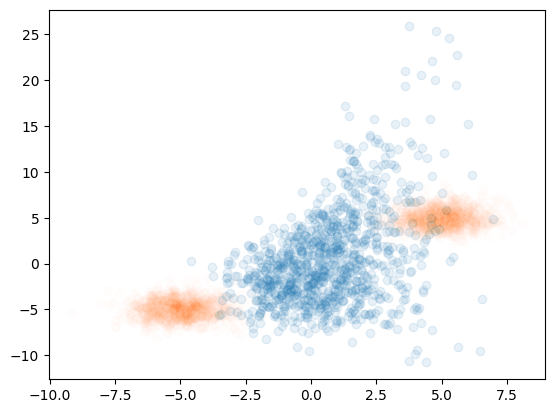

In [8]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [9]:
x = jnp.ones((10,input_dim))
y = T(params, x)


q._inv_and_logdet(y)

(Array([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]], dtype=float32),
 Array([-2.356, -2.356, -2.356, -2.356, -2.356, -2.356, -2.356, -2.356,
        -2.356, -2.356], dtype=float32))

In [11]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [12]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

9.138647
3.891492
3.7491593
3.651195
3.6024406


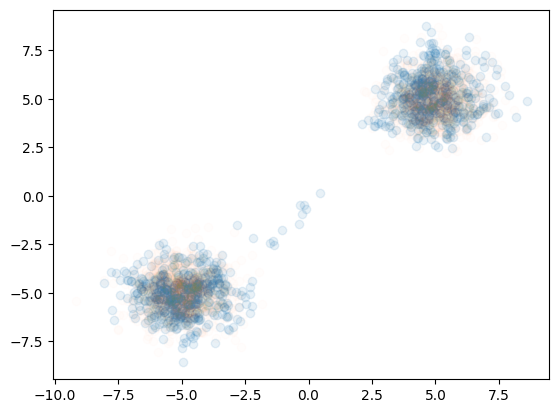

In [13]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

## Spline flows

In [21]:
input_dim = 4
from functools import partial
@partial(jax.vmap, in_axes=(None, 0))
def spline_bijector(params, x):
    return rational_quadratic_spline(params, x, range_min_x=-4, range_max_x=4,range_min_y = -15., range_max_y=15.)

num_bins = 6
bijector_dim = (3 * num_bins)
split_dim = 3

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(1, spline_bijector, bijector_dim),Flip(), CouplingMLP(1, spline_bijector, bijector_dim), Flip()])
    return nn(x)

init, apply = forward.init, forward.apply
params = init(jax.random.PRNGKey(0), jnp.ones((input_dim,)))
T = apply

In [22]:
f = lambda x: T(params, x)



In [38]:
f_inv_and_logdet = inverse_and_logabsdet(f)

In [13]:
y = f(jnp.ones((input_dim,)))
y

Array([0.426, 0.426, 0.426, 3.748], dtype=float32)

In [35]:
f_inv(y)

rev [False] [True]
pjit [False] [True]
concatenate [False, False] [True]
dot_general [True, True] [False]
add [True, True] [False]
custom_jvp_call [True] [False]
dot_general [True, True] [False]
add [True, True] [False]
custom_jvp_call [True] [False]
dot_general [True, True] [False]
add [True, True] [False]
custom_inverse_call_p [True, False] [True]
slice [False] [True]
slice [True] [True]
rev [False] [True]
pjit [False] [True]
concatenate [False, False] [True]
dot_general [True, True] [False]
add [True, True] [False]
custom_jvp_call [True] [False]
dot_general [True, True] [False]
add [True, True] [False]
custom_jvp_call [True] [False]
dot_general [True, True] [False]
add [True, True] [False]
custom_inverse_call_p [True, False] [True]
slice [False] [True]
slice [True] [True]


Array([1., 1.], dtype=float32)

In [36]:
f_inv_and_logdet(y)

(Array([1., 1.], dtype=float32), Array(-0.271, dtype=float32))

In [15]:
y = apply(params, jnp.ones((input_dim)))

q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

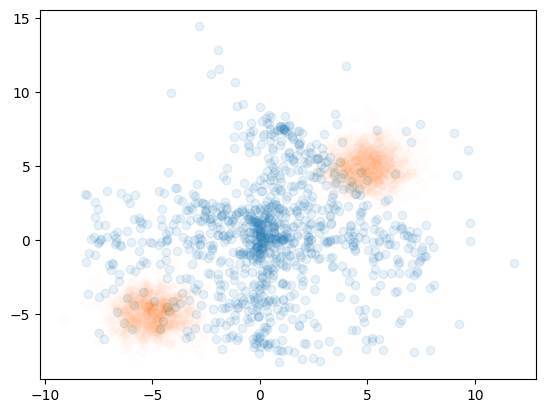

In [16]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [19]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [20]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

3.5550747
3.5222561


KeyboardInterrupt: 

In [18]:
q = TransformedDistribution(p, lambda x: apply(params, x))
samples = q.sample(jax.random.PRNGKey(0), sample_shape=(1000,))

(-10.0, 10.0)

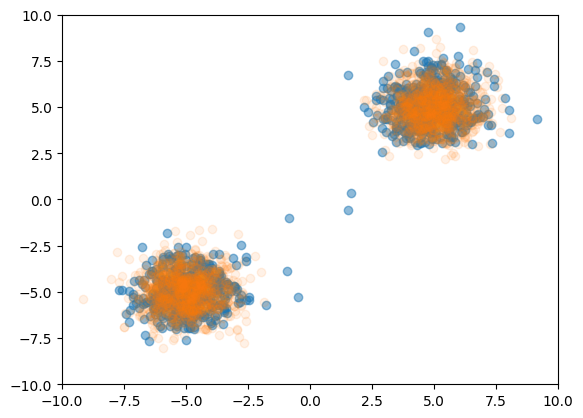

In [19]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Gaussianization flow

Here we do not even need any neural nets!

In [20]:
from probjax.nn.helpers import Rotate

spline_based = jax.vmap(spline_bijector, in_axes=(-1, -1))

@hk.without_apply_rng
@hk.transform
def f(x):
    r1 = Rotate(jax.random.PRNGKey(0), 2)
    r2 = Rotate(jax.random.PRNGKey(1), 2)
    r3 = Rotate(jax.random.PRNGKey(2), 2)

    params1 = hk.get_parameter("params_spline1", shape=(12,2), init=hk.initializers.RandomNormal(0.1)   )
    params2 = hk.get_parameter("params_spline2", shape=(12,2), init=hk.initializers.RandomNormal(0.1)  )
    params3 = hk.get_parameter("params_spline3", shape=(12,2), init=hk.initializers.RandomNormal(0.1)  )
    params4 = hk.get_parameter("params_spline4", shape=(12,2), init=hk.initializers.RandomNormal(0.1)  )

    x1 = spline_based(params1, x)
    x2 = r1(x1)
    x3 = spline_based(params2, x2)
    x4 = r2(x3)
    x5 = spline_based(params3, x4)
    x6 = r3(x5)
    x7 = spline_based(params4, x6)

    return x7

init, apply = f.init, f.apply

params = init(jax.random.PRNGKey(0), jnp.ones((input_dim,)))

T = apply

In [21]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

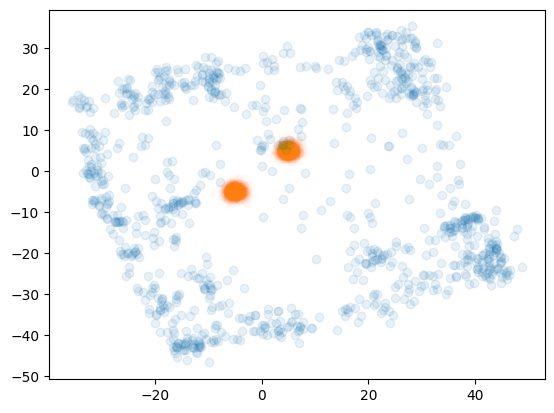

In [22]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [23]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [24]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

10.615106
4.299103
3.7469084
3.69427
3.6351552


In [25]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

(-10.0, 10.0)

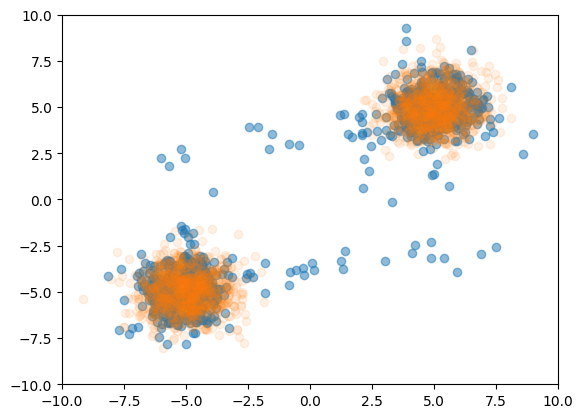

In [26]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)

In [27]:
from probjax.nn.bijective import learnable_mixture_cdf

In [28]:
from probjax.nn.helpers import Rotate, rotate
# Affine can only be Gaussian!



@hk.without_apply_rng
@hk.transform
def f(x):

    params1 = hk.get_parameter("params_affine1", shape=(2,50), init=hk.initializers.RandomNormal(0.1))
    params2 = hk.get_parameter("params_affine2", shape=(2,50), init=hk.initializers.RandomNormal(0.1))
    params3 = hk.get_parameter("params_affine3", shape=(2,50), init=hk.initializers.RandomNormal(0.1))
    params4 = hk.get_parameter("params_affine4", shape=(2,50), init=hk.initializers.RandomNormal(0.1))

    rot1 = hk.get_parameter("r1", shape=(2,2),init=hk.initializers.RandomNormal(0.1))
    rot2 = hk.get_parameter("r2", shape=(2,2),init=hk.initializers.RandomNormal(0.1))
    rot3 = hk.get_parameter("r3", shape=(2,2),init=hk.initializers.RandomNormal(0.1))

    rot1 = jnp.linalg.qr(rot1)[0]
    rot2 = jnp.linalg.qr(rot2)[0]
    rot3 = jnp.linalg.qr(rot3)[0]

    x1 = learnable_mixture_cdf(params1, x)
    x2 = rotate(rot1, x1)
    x3 = learnable_mixture_cdf(params2, x2)
    x4 = rotate(rot2, x3)
    x5 = learnable_mixture_cdf(params3, x4)
    x6 = rotate(rot3, x5)
    x7 = learnable_mixture_cdf(params4, x6)

    return x7

init, apply = f.init, f.apply

params = init(jax.random.PRNGKey(0), jnp.ones((input_dim,)))

T = apply

In [29]:
learnable_mixture_cdf(params["~"]["params_affine1"], 0.4*jnp.ones((input_dim)))

Array([0.666, 0.727], dtype=float32)

In [30]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

In [31]:
samples

Array([[ 1.89 ,  1.194],
       [10.   ,  9.706],
       [10.   ,  5.744],
       ...,
       [ 5.008, 10.   ],
       [10.   , 10.   ],
       [ 4.321, 10.   ]], dtype=float32)

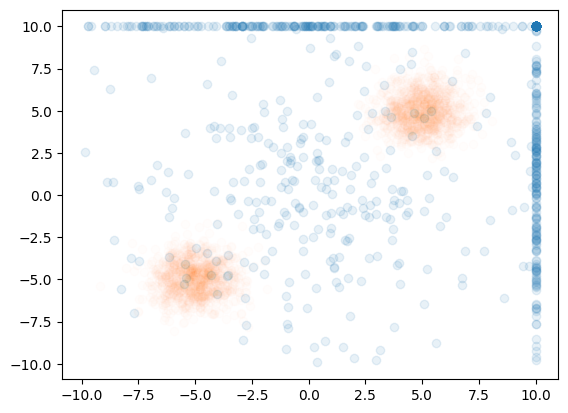

In [32]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [33]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [34]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

7.7765713
4.035629
3.6147213
3.5648577
3.5141432


In [35]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

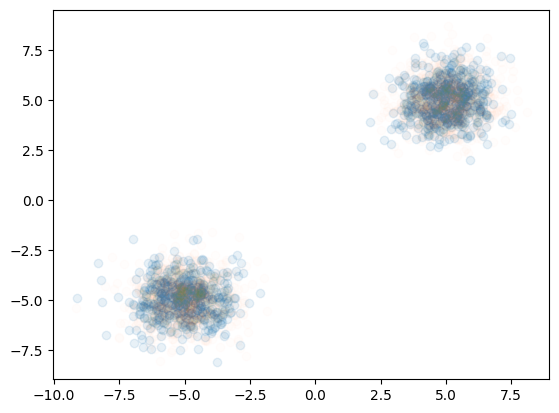

In [36]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

# Continous normalizing flows

In [37]:
from probjax.utils.odeint import odeint
from probjax.nn.helpers import TimeEmbedding#


def net(t, x):
    #print("Net", t,x)
    t = jnp.array(t).reshape(-1)
    t = TimeEmbedding(4)(t)
    return hk.nets.MLP([50, 50, 2], activation=jnp.tanh)(jnp.concatenate([t, x], axis=-1))


init, f = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones(1), jnp.ones((2,)))

t = jnp.linspace(0, 1, 100)

def T(params, x):
    ys =  odeint(lambda t, x: f(params, t, x), x, jnp.linspace(0, 1, 100))
    return ys[-1]

q = TransformedDistribution(p, lambda x: T(params, x))

samples = q.sample(jax.random.PRNGKey(0 ), (1000,))
log_prob = q.log_prob(samples)

In [38]:
optimizer = adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()
    
@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [39]:
for i in range(100):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (256,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 50 == 0:
        print(loss)

29.182076
3.6016078


In [40]:

q = TransformedDistribution(p, lambda x: T(params, x))

samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

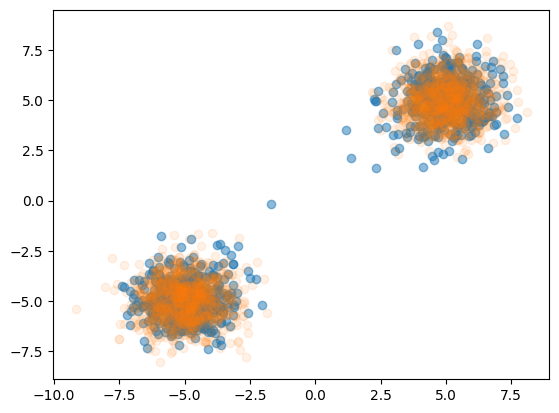

In [41]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)


# Flow matching

Flow Matching Objective (FM): The paper introduces the Flow Matching objective, which aims to match a target probability distribution to a known distribution by regressing a vector field. The goal is to flow from a simple distribution (e.g., standard normal) to a target distribution that closely approximates the data distribution.

Conditional Probability Paths and Vector Fields: To achieve the Flow Matching objective, the paper discusses the construction of conditional probability paths (pt(x|x1)) and vector fields (ut(x|x1)) per data sample. These conditional paths and fields are essential for modeling the target probability distribution.

Theorems: The paper presents several theorems, notably Theorem 1 and Theorem 2. Theorem 1 shows that the marginal vector field (ut) generates the marginal probability path (pt), linking conditional and marginal modeling. Theorem 2 demonstrates the equivalence of the Conditional Flow Matching (CFM) objective to the original FM objective, making CFM a more tractable choice.

Conditional Flow Matching (CFM): Due to intractable integrals in the original FM objective, the paper proposes CFM as a simpler alternative. CFM allows for easy unbiased sampling estimates and has identical gradients to the FM objective. It is defined by the loss function:

scss
Copy code
LCFM(θ) = Et,q(x1),pt(x|x1) [||vt(x) - ut(x|x1)||^2]
Construction of Conditional Paths: The paper provides examples of constructing conditional Gaussian probability paths, including diffusion conditional paths and optimal transport conditional paths.


In [58]:
from probjax.utils.odeint import _odeint as odeint
from probjax.nn.helpers import TimeEmbedding
from functools import partial
input_dim = 2
hidden_dim = 50
def net(t, x):
    t = jnp.array(t).reshape(-1)
    t = TimeEmbedding(hidden_dim)(t)
    
    h1_x = hk.Linear(hidden_dim)(x)
    h1_t = hk.Linear(hidden_dim)(t)
    h1 = jax.nn.swish(h1_x + h1_t) 
    h2 = hk.Linear(hidden_dim)(h1)
    h2_t = hk.Linear(hidden_dim)(t)
    h2 = jax.nn.swish(h2 + h2_t) + h1
    h3 = hk.Linear(hidden_dim)(h2)
    h3_t = hk.Linear(hidden_dim)(t)
    h3 = jax.nn.swish(h3 + h3_t) + h2
    h4_x = hk.Linear(hidden_dim)(h3)
    h4_t = hk.Linear(hidden_dim)(t)
    h4 = jax.nn.swish(h4_x + h4_t) + h3

    

    out = hk.Linear(input_dim)(h4)
    return out
    
init, forward = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones(1), jnp.ones((2,)))

ts = jnp.linspace(0, 1, 200)

def drift(t, x, params):
    return forward(params, t, x)


In [65]:
sigma_min = 1e-2

# Train as if it would be a diffusion process
def loss_fn(params, key, x1):
    """ Optimal transport flow-matching loss.
    """
    key1, key2, key3 = jax.random.split(key, 3)
    t = jax.random.uniform(key1, (x1.shape[0], 1))
    x0 = jax.random.normal(key2, x1.shape)


   # One possibility
    # Optimal transport paths
    xt = (1 - (1-sigma_min) * t) * x0  + t*x1
    u = x1 - (1-sigma_min) * x0

    # Other: This does not work
    # xt = t * x1 + (t * sigma_min - t + 1) * noise
    # u = (x1 - (1- sigma_min) * x0) / (1 - (1- sigma_min) * t)

    v_t = jax.vmap(drift, in_axes=(0,0, None))(t, xt, params)

    return jnp.mean(jnp.sum(jnp.square(v_t - u), -1))

optimizer = adam(1e-3)
opt_state = optimizer.init(params)
    
@jax.jit
def step(params, opt_state, key, x):
    loss, g = jax.value_and_grad(loss_fn)(params, key,x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [67]:
for i in range(1000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, jax.random.PRNGKey(i + 10000),xs_batch)
    if i % 100 == 0:
        print(loss)

9.849888
8.80787
9.799394
10.3965025
9.924911
9.043004
10.513955
10.585065
9.500655
10.244795


In [68]:
def sample(params, key, shape):
    z0 = jax.random.normal(key, shape + (2,))
    def f(x0):
        return odeint(lambda t, x: drift(t, x, params), x0, jnp.linspace(0,1, 200), method="rk4")[-1]
    z1 = jax.vmap(f)(z0)
    return z1

In [69]:
samples = sample(params, jax.random.PRNGKey(0), (1000,))

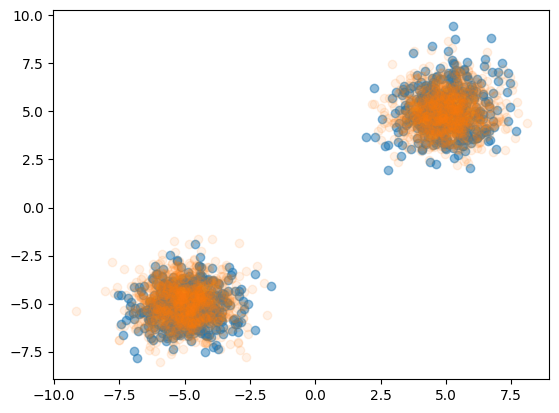

In [72]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)
